<a href="https://colab.research.google.com/github/Shahla-AAFS/Nail_disorder_detection/blob/main/Nail_disorder_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/main nail dataset"

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [3]:
dataset_path = "/content/drive/MyDrive/main nail dataset"

In [4]:
import os
print(os.listdir("/content/drive/MyDrive/main nail dataset"))

['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']


In [5]:
!pip install split-folders

In [6]:
import splitfolders

splitfolders.ratio(
    "/content/drive/MyDrive/main nail dataset",
    output="/content/nail_split",
    seed=42,
    ratio=(0.8, 0.2)   # 80% train, 20% validation
)

Copying files: 4147 files [01:26, 47.73 files/s] 


In [7]:
!ls /content/nail_split

train  val


In [8]:
!ls /content/nail_split/train

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [9]:
!ls /content/nail_split/val

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [10]:
!ls /content/drive/MyDrive/nail_split

train  val


In [ ]:
!ls -lh /content/drive/MyDrive/

total 116M
drwx------ 2 root root 4.0K Nov 27  2023  01-11-2023
drwx------ 2 root root 4.0K Nov 23  2023  2020ICT12
-rw------- 1 root root  176 May 16  2024 '2020ICT12-Assignment 01.gdoc'
drwx------ 2 root root 4.0K Jun 26  2024 '2020ICT12 -  assignment-06'
-rw------- 1 root root  176 Jun 12  2025 '2020ICT12_Practical Assessment – Advanced SQL Concepts.gdoc'
-rw------- 1 root root  176 May 16  2025 '2020ICT12_SQL Constraints Exercise Sheet.gdoc'
-rw------- 1 root root  176 May 17  2025 '2020ICT12_Stored PROCEDURE_class work.gdoc'
-rw------- 1 root root  176 May 29  2025  2020_ICT12_TRANSACTION.gdoc
-rw------- 1 root root  176 Jun  5  2025 '2020ict12_TRIGGERS CLASSWORK.gdoc'
-rw------- 1 root root  176 Jun 11  2025 '2022_ In-Course Assessment Examination - I.gdoc'
drwx------ 2 root root 4.0K Apr 25  2024  25.04.2024
drwx------ 2 root root 4.0K Apr 29  2024  28.04.2024
drwx------ 2 root root 4.0K Apr  8  2024  4.4.2024
-rw------- 1 root root 872K Jan 17  2023  90ae48bb7eb843bbb3397fb63ed

In [ ]:
!cp -rv /content/nail_split /content/drive/MyDrive/

'/content/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-20-at-10-24-29-PM_png.rf.56724e81eeec07272eea77d625c27875.jpg' -> '/content/drive/MyDrive/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-20-at-10-24-29-PM_png.rf.56724e81eeec07272eea77d625c27875.jpg'
'/content/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-20-at-8-21-24-PM_png.rf.d9fc5737863df25b69be62b77cee1922.jpg' -> '/content/drive/MyDrive/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-20-at-8-21-24-PM_png.rf.d9fc5737863df25b69be62b77cee1922.jpg'
'/content/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-19-at-1-38-32-AM_png.rf.e0d109e50123045f7f52d6134c28385a.jpg' -> '/content/drive/MyDrive/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-19-at-1-38-32-AM_png.rf.e0d109e50123045f7f52d6134c28385a.jpg'
'/content/nail_split/train/Acral_Lentiginous_Melanoma/Screen-Shot-2021-11-19-at-1-27-44-AM_png.rf.7d335a64bfa341f5f6116e5b00d81beb.

In [7]:
#check if the splitted folders are exist inside drive
import os

base_path = "/content/drive/MyDrive/nail_split"
print("Train classes:", os.listdir(os.path.join(base_path, "train")))
print("Validation classes:", os.listdir(os.path.join(base_path, "val")))

Train classes: ['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']
Validation classes: ['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']


In [8]:
#Install  import all libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#confirm GPU available
print("TF version :", tf.__version__)
print("GPU devices :",tf.config.list_physical_devices('GPU'))

TF version : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
#  Global config
BASE_PATH = "/content/drive/MyDrive/nail_split"
TRAIN_DIR = os.path.join(BASE_PATH, "train")
VAL_DIR = os.path.join(BASE_PATH, "val")

IMG_SIZE     = (224, 224)  #same for all 3 models
BATCH_SIZE   = 16
NUM_CLASSES  = 6
SEED         = 42

CLASS_NAMES = [
    'Acral_Lentiginous_Melanoma',
    'Onychogryphosis',
    'blue_finger',
    'pitting',
    'clubbing',
    'Healthy_Nail'
]

print("Classes :", CLASS_NAMES)
print("Train dir exists :", os.path.exists(TRAIN_DIR))
print("Val   dir exists :", os.path.exists(VAL_DIR))

Classes : ['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']
Train dir exists : True
Val   dir exists : True


In [10]:
#  Count images per class (sanity check before training)
def count_images(directory, class_names):
    print(f"\n{'Class':<35} {'Count':>6}")
    print("-" * 43)
    total = 0
    for cls in class_names:
        cls_path = os.path.join(directory, cls)
        if os.path.exists(cls_path):
            n = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])
            print(f"  {cls:<33} {n:>6}")
            total += n
        else:
            print(f"  {cls:<33} {'MISSING':>6}")
    print("-" * 43)
    print(f"  {'TOTAL':<33} {total:>6}\n")
    return total

print("=== TRAINING SET ===")
train_total = count_images(TRAIN_DIR, CLASS_NAMES)

print("=== VALIDATION SET ===")
val_total = count_images(VAL_DIR, CLASS_NAMES)

=== TRAINING SET ===

Class                                Count
-------------------------------------------
  Acral_Lentiginous_Melanoma           604
  Onychogryphosis                      551
  blue_finger                          489
  pitting                              524
  clubbing                             626
  Healthy_Nail                         522
-------------------------------------------
  TOTAL                               3316

=== VALIDATION SET ===

Class                                Count
-------------------------------------------
  Acral_Lentiginous_Melanoma           151
  Onychogryphosis                      138
  blue_finger                          123
  pitting                              131
  clubbing                             157
  Healthy_Nail                         131
-------------------------------------------
  TOTAL                                831



In [11]:
# CELL 5 — Build data generators
#
# KEY RULES:
#   - Augmentation is applied to TRAINING set ONLY
#   - Validation generator only does rescaling — NO augmentation
#   - All 3 models use the same generators (fair comparison)
#   - rescale=1./255 brings pixels from [0,255] -> [0,1]
#     then ImageNet mean/std normalization is handled inside each model's
#     preprocess_input call (see Cell 6 per-model loaders)
# -----------------------------------------------------------------------------

# --- Training augmentation ---
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = 15,
    zoom_range         = 0.2,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

# --- Validation: NO augmentation, only rescale ---
val_datagen = ImageDataGenerator(
    rescale = 1.0 / 255
)

# --- Training generator ---
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = True,
    seed         = SEED
)

# --- Validation generator ---
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False          # IMPORTANT: keep False for validation
)

print("\nClass index mapping:", train_generator.class_indices)
print("Train batches  :", len(train_generator))
print("Val   batches  :", len(val_generator))

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.

Class index mapping: {'Acral_Lentiginous_Melanoma': 0, 'Healthy_Nail': 1, 'Onychogryphosis': 2, 'blue_finger': 3, 'clubbing': 4, 'pitting': 5}
Train batches  : 208
Val   batches  : 52


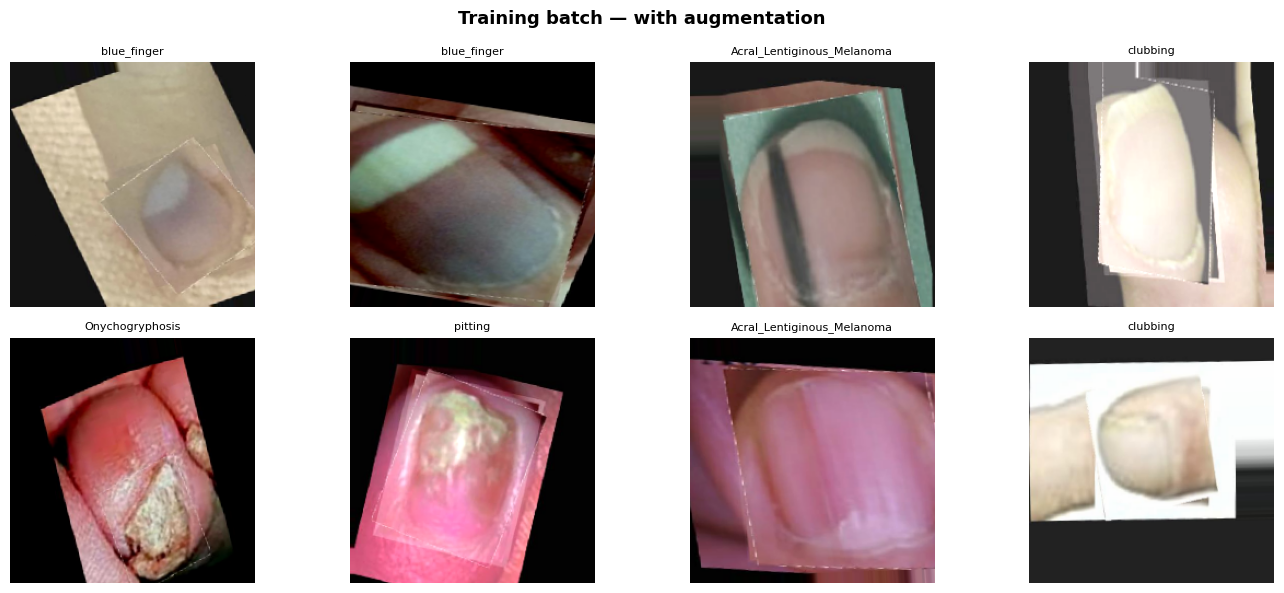

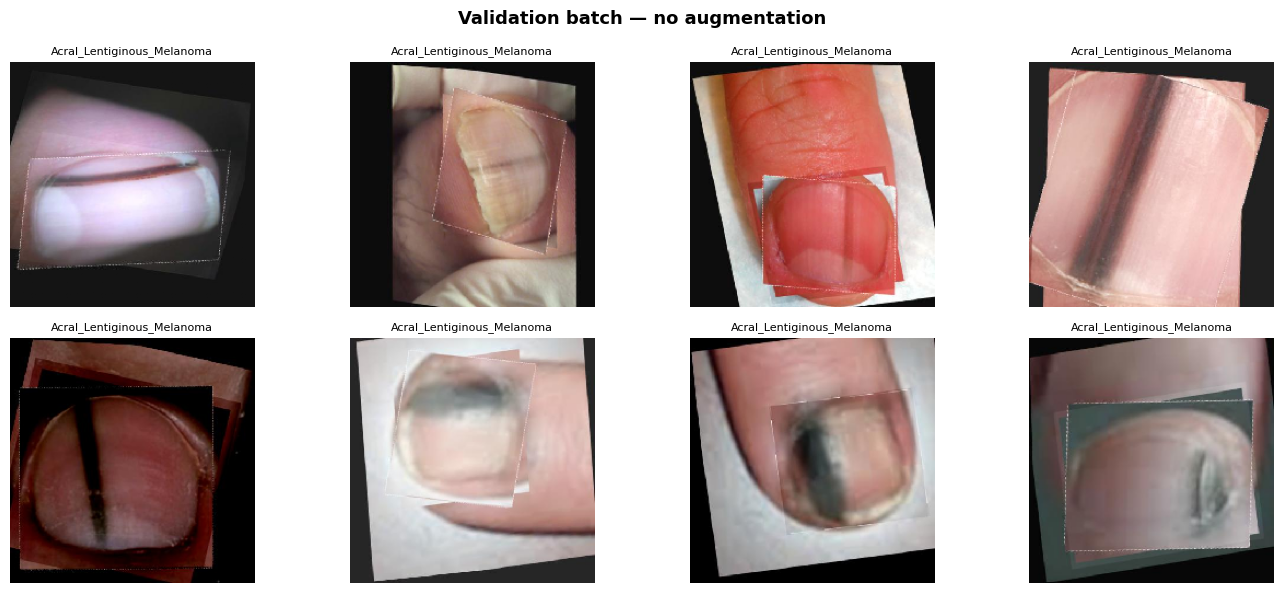

In [12]:
#CELL 6 — Visualise a sample batch (verify augmentation looks correct)

def show_batch(generator, title="Sample batch", n=8):
    images, labels = next(generator)
    class_idx_inv  = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            ax.axis('off')
            continue
        ax.imshow(np.clip(images[i], 0, 1))
        label_idx = np.argmax(labels[i])
        ax.set_title(class_idx_inv[label_idx], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_generator, title="Training batch — with augmentation")
show_batch(val_generator,   title="Validation batch — no augmentation")

In [13]:
#CELL 7 — Build Model A: MobileNetV2
# Strategy (two-phase transfer learning):
#   Phase 1: freeze entire backbone, train only the custom head (5-10 epochs)
#   Phase 2: unfreeze top layers, fine-tune with very low LR (10-20 epochs)
# -----------------------------------------------------------------------------

def build_mobilenetv2(num_classes, img_size=(224, 224)):
    base = tf.keras.applications.MobileNetV2(
        input_shape = (*img_size, 3),
        include_top = False,
        weights     = 'imagenet'
    )
    base.trainable = False          # Phase 1: freeze backbone

    inputs = keras.Input(shape=(*img_size, 3))
    # MobileNetV2 preprocess_input scales [0,1] -> [-1, 1] (its expected range)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_Transfer")
    return model, base

mobilenet_model, mobilenet_base = build_mobilenetv2(NUM_CLASSES)
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# CELL 10 — Callbacks (used during training for all 3 models)
#
# - EarlyStopping: stops training if val_loss doesn't improve for 5 epochs
# - ModelCheckpoint: saves the best weights automatically to Drive
# - ReduceLROnPlateau: cuts learning rate if plateau detected
# -----------------------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/nail_models"
os.makedirs(SAVE_DIR, exist_ok=True)

def get_callbacks(model_name, phase):
    return [
        keras.callbacks.EarlyStopping(
            monitor   = 'val_loss',
            patience  = 5,
            restore_best_weights = True,
            verbose   = 1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath  = os.path.join(SAVE_DIR, f"{model_name}_phase{phase}_best.h5"),
            monitor   = 'val_accuracy',
            save_best_only = True,
            verbose   = 1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor   = 'val_loss',
            factor    = 0.5,
            patience  = 3,
            min_lr    = 1e-7,
            verbose   = 1
        )
    ]


In [16]:
# CELL 11 — PHASE 1 TRAINING: MobileNetV2 (frozen backbone, train head only)
# -----------------------------------------------------------------------------

mobilenet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("=== MobileNetV2 — Phase 1 (head only) ===")
history_mob_p1 = mobilenet_model.fit(
    train_generator,
    epochs          = 10,
    validation_data = val_generator,
    callbacks       = get_callbacks("mobilenetv2", phase=1),
    verbose         = 1
)

=== MobileNetV2 — Phase 1 (head only) ===
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.5515 - loss: 1.2155 
Epoch 1: val_accuracy improved from None to 0.78460, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 3389s 16s/step - accuracy: 0.6457 - loss: 0.9342 - val_accuracy: 0.7846 - val_loss: 0.6414 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7499 - loss: 0.6518
Epoch 2: val_accuracy improved from 0.78460 to 0.82792, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 66s 316ms/step - accuracy: 0.7518 - loss: 0.6541 - val_accuracy: 0.8279 - val_loss: 0.4907 - learning_rate: 0.0010
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7751 - loss: 0.5928
Epoch 3: val_accuracy improved from 0.82792 to 0.83153, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 315ms/step - accuracy: 0.7774 - loss: 0.5655 - val_accuracy: 0.8315 - val_loss: 0.4713 - learning_rate: 0.0010
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8040 - loss: 0.5157
Epoch 4: val_accuracy improved from 0.83153 to 0.83634, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 66s 319ms/step - accuracy: 0.8076 - loss: 0.5179 - val_accuracy: 0.8363 - val_loss: 0.4941 - learning_rate: 0.0010
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8288 - loss: 0.4693
Epoch 5: val_accuracy did not improve from 0.83634
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 311ms/step - accuracy: 0.8221 - loss: 0.4837 - val_accuracy: 0.8339 - val_loss: 0.4573 - learning_rate: 0.0010
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8172 - loss: 0.4802
Epoch 6: val_accuracy improved from 0.83634 to 0.83875, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 314ms/step - accuracy: 0.8133 - loss: 0.4904 - val_accuracy: 0.8387 - val_loss: 0.4553 - learning_rate: 0.0010
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.8421 - loss: 0.4313
Epoch 7: val_accuracy did not improve from 0.83875
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 315ms/step - accuracy: 0.8347 - loss: 0.4392 - val_accuracy: 0.8075 - val_loss: 0.5425 - learning_rate: 0.0010
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.8274 - loss: 0.4357
Epoch 8: val_accuracy did not improve from 0.83875
208/208 ━━━━━━━━━━━━━━━━━━━━ 64s 306ms/step - accuracy: 0.8347 - loss: 0.4230 - val_accuracy: 0.7978 - val_loss: 0.5169 - learning_rate: 0.0010
Epoch 9/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8345 - loss: 0.4278
Epoch 9: val_accuracy improved from 0.83875 to 0.84356, saving model to /content/drive/MyDrive/nail_model


Epoch 9: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 314ms/step - accuracy: 0.8369 - loss: 0.4318 - val_accuracy: 0.8436 - val_loss: 0.4300 - learning_rate: 0.0010
Epoch 10/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8578 - loss: 0.3729
Epoch 10: val_accuracy improved from 0.84356 to 0.84597, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5



Epoch 10: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 67s 320ms/step - accuracy: 0.8549 - loss: 0.3846 - val_accuracy: 0.8460 - val_loss: 0.4258 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [17]:
# Unfreeze the top 30 layers of the backbone
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
mobilenet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("=== MobileNetV2 — Phase 2 (fine-tuning) ===")
history_mob_p2 = mobilenet_model.fit(
    train_generator,
    epochs          = 20,
    validation_data = val_generator,
    callbacks       = get_callbacks("mobilenetv2", phase=2),
    verbose         = 1
)

=== MobileNetV2 — Phase 2 (fine-tuning) ===
Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5892 - loss: 1.5537
Epoch 1: val_accuracy improved from None to 0.82190, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 102s 402ms/step - accuracy: 0.6641 - loss: 1.1376 - val_accuracy: 0.8219 - val_loss: 0.5529 - learning_rate: 1.0000e-05
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.7719 - loss: 0.6067
Epoch 2: val_accuracy improved from 0.82190 to 0.82671, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 68s 328ms/step - accuracy: 0.7786 - loss: 0.5882 - val_accuracy: 0.8267 - val_loss: 0.5537 - learning_rate: 1.0000e-05
Epoch 3/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8027 - loss: 0.5565
Epoch 3: val_accuracy improved from 0.82671 to 0.84958, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 83s 331ms/step - accuracy: 0.8124 - loss: 0.5254 - val_accuracy: 0.8496 - val_loss: 0.4817 - learning_rate: 1.0000e-05
Epoch 4/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8281 - loss: 0.4920
Epoch 4: val_accuracy improved from 0.84958 to 0.85439, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 69s 331ms/step - accuracy: 0.8260 - loss: 0.4845 - val_accuracy: 0.8544 - val_loss: 0.4548 - learning_rate: 1.0000e-05
Epoch 5/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8504 - loss: 0.4198
Epoch 5: val_accuracy improved from 0.85439 to 0.85680, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5


...


Epoch 12: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 70s 335ms/step - accuracy: 0.8908 - loss: 0.3048 - val_accuracy: 0.8929 - val_loss: 0.2968 - learning_rate: 1.0000e-05
Epoch 13/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.8760 - loss: 0.3276
Epoch 13: val_accuracy improved from 0.89290 to 0.90012, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 13: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 69s 332ms/step - accuracy: 0.8785 - loss: 0.3216 - val_accuracy: 0.9001 - val_loss: 0.2845 - learning_rate: 1.0000e-05
Epoch 14/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8994 - loss: 0.2706
Epoch 14: val_accuracy did not improve from 0.90012
208/208 ━━━━━━━━━━━━━━━━━━━━ 68s 328ms/step - accuracy: 0.9002 - loss: 0.2668 - val_accuracy: 0.8977 - val_loss: 0.2792 - learning_rate: 1.0000e-05
Epoch 15/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.9130 - loss: 0.2569
Epoch 15: val_accuracy improved from 0.90012 to 0.90253, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 15: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 69s 329ms/step - accuracy: 0.9083 - loss: 0.2614 - val_accuracy: 0.9025 - val_loss: 0.2803 - learning_rate: 1.0000e-05
Epoch 16/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9068 - loss: 0.2684
Epoch 16: val_accuracy did not improve from 0.90253
208/208 ━━━━━━━━━━━━━━━━━━━━ 81s 325ms/step - accuracy: 0.9101 - loss: 0.2645 - val_accuracy: 0.9025 - val_loss: 0.2797 - learning_rate: 1.0000e-05
Epoch 17/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9076 - loss: 0.2646
Epoch 17: val_accuracy improved from 0.90253 to 0.90854, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 17: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 70s 335ms/step - accuracy: 0.9077 - loss: 0.2638 - val_accuracy: 0.9085 - val_loss: 0.2620 - learning_rate: 1.0000e-05
Epoch 18/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9283 - loss: 0.2199
Epoch 18: val_accuracy did not improve from 0.90854
208/208 ━━━━━━━━━━━━━━━━━━━━ 69s 330ms/step - accuracy: 0.9222 - loss: 0.2233 - val_accuracy: 0.9013 - val_loss: 0.2665 - learning_rate: 1.0000e-05
Epoch 19/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9182 - loss: 0.2223
Epoch 19: val_accuracy improved from 0.90854 to 0.90975, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5



Epoch 19: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.h5
208/208 ━━━━━━━━━━━━━━━━━━━━ 68s 326ms/step - accuracy: 0.9201 - loss: 0.2210 - val_accuracy: 0.9097 - val_loss: 0.2589 - learning_rate: 1.0000e-05
Epoch 20/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9177 - loss: 0.2172
Epoch 20: val_accuracy did not improve from 0.90975
208/208 ━━━━━━━━━━━━━━━━━━━━ 66s 317ms/step - accuracy: 0.9189 - loss: 0.2167 - val_accuracy: 0.9085 - val_loss: 0.2509 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 20.


In [ ]:
############
# this is earliest way please , omit it




from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --------------------------
# 1️⃣ Data Augmentation for training
# --------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=(0.7, 1.3),
    channel_shift_range=10
)

# Validation: only rescaling
val_datagen = ImageDataGenerator(rescale=1./255)

# --------------------------
# 2️⃣ Data Generators
# --------------------------
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class indices from the generator
classes = train_generator.classes  # array of class labels in train set
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

# Convert to dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.9150110375275938), 1: np.float64(1.0587484035759898), 2: np.float64(1.0030248033877798), 3: np.float64(1.1301976823449216), 4: np.float64(0.8828541001064962), 5: np.float64(1.05470737913486)}


In [ ]:
# convert the weights to a dictionary before training
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(0.9150110375275938), 1: np.float64(1.0587484035759898), 2: np.float64(1.0030248033877798), 3: np.float64(1.1301976823449216), 4: np.float64(0.8828541001064962), 5: np.float64(1.05470737913486)}


In [ ]:
# do augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --------------------------
# 1️⃣ Data Augmentation (Fixed)
# --------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # normalization (no rescale needed)

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.2,
    shear_range=0.1,

    horizontal_flip=True
)

# Validation: only preprocessing (NO augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# --------------------------
# 2️⃣ Data Generators
# --------------------------
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.


In [ ]:
#build MobileNetV2 model(lightweight and strong baseline)
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

#Freeze base layers
for layer in base_model.layers:
  layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/model_checkpoint.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
#model training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    class_weight=class_weights_dict
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1282s 12s/step - accuracy: 0.6434 - loss: 0.9528 - val_accuracy: 0.7875 - val_loss: 0.6315
Epoch 2/10
  1/103 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7500 - loss: 0.6787

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


103/103 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.7500 - loss: 0.6787 - val_accuracy: 0.7825 - val_loss: 0.6291
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 559ms/step - accuracy: 0.7677 - loss: 0.6233 - val_accuracy: 0.8087 - val_loss: 0.5410
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6875 - loss: 0.7848 - val_accuracy: 0.7887 - val_loss: 0.5666
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 559ms/step - accuracy: 0.7844 - loss: 0.5438 - val_accuracy: 0.8025 - val_loss: 0.5414
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7188 - loss: 0.7320 - val_accuracy: 0.8075 - val_loss: 0.5316
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 555ms/step - accuracy: 0.8118 - loss: 0.5023 - val_accuracy: 0.8112 - val_loss: 0.5267
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7500 - loss: 0.4947 - val_accuracy: 0.8100 - val_loss: 0.5328
Epoch 9/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 58s 564ms/step - accuracy: 0.8304 - loss: 0.4557 - val_accur

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.90625
Final Validation Accuracy: 0.8387500047683716
Final Training Loss: 0.30809226632118225
Final Validation Loss: 0.4524781405925751


In [ ]:

#Observations:

#Your training and validation accuracy are very close → minimal overfitting ✅

#Validation accuracy is strong for a first baseline with frozen MobileNetV2

#This gives a solid foundation for research

In [ ]:
#Optional Fine-Tuning MobileNetV2 (Boost Accuracy)
#Unfreeze last 20–30 layers and train with a smaller learning rate:
for layer in base_model.layers[-30:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
   train_generator,
    validation_data=train_generator,
    epochs=5,
    class_weight=class_weights_dict
)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6206 - loss: 1.1470 - val_accuracy: 0.8444 - val_loss: 0.4229
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.7829 - loss: 0.5933 - val_accuracy: 0.8450 - val_loss: 0.4295
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8118 - loss: 0.4978 - val_accuracy: 0.8390 - val_loss: 0.4249
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8281 - loss: 0.4585 - val_accuracy: 0.8486 - val_loss: 0.4049
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8323 - loss: 0.4395 - val_accuracy: 0.8586 - val_loss: 0.3755


In [ ]:
print("Training Accuracy After fine-tuning:", history_fine.history['accuracy'][-1])
print("Validation Accuracy After fine-tuning:", history_fine.history['val_accuracy'][-1])

Training Accuracy After fine-tuning: 0.8323280811309814
Validation Accuracy After fine-tuning: 0.858564555644989


In [ ]:
#The MobileNetV2 model achieved a validation accuracy of 83.88% before fine-tuning and improved to 85.86% after fine-tuning.
 #Although the training accuracy decreased during fine-tuning, the validation accuracy increased, indicating improved generalization
 #and reduced overfitting.
 #This demonstrates that fine-tuning the deeper layers of the network enhances the model’s ability to classify unseen nail disease images effectively.
#Therefore, MobileNetV2 can be considered a strong and efficient baseline model for this classification task.

In [ ]:
#second model restnet50
#preprocessing
# ResNet50 Augmentation + Preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training: augmentation + preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # IMPORTANT for ResNet50

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation: ONLY preprocessing
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.


In [ ]:
#build the restNet50 mode
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,121,990 (92.02 MB)

 Trainable params: 530,182 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
#train the model RestNet50
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)


Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1017s 10s/step - accuracy: 0.3197 - loss: 1.6976 - val_accuracy: 0.1661 - val_loss: 1.9279
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 68s 654ms/step - accuracy: 0.3562 - loss: 1.5488 - val_accuracy: 0.2708 - val_loss: 1.7459
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 68s 650ms/step - accuracy: 0.4065 - loss: 1.4569 - val_accuracy: 0.3129 - val_loss: 1.5899
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 67s 644ms/step - accuracy: 0.4156 - loss: 1.4236 - val_accuracy: 0.3875 - val_loss: 1.4668
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 68s 651ms/step - accuracy: 0.4171 - loss: 1.3963 - val_accuracy: 0.4621 - val_loss: 1.3693
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 69s 658ms/step - accuracy: 0.4174 - loss: 1.3768 - val_accuracy: 0.5042 - val_loss: 1.2484
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 67s 645ms/step - accuracy: 0.4294 - loss: 1.3371 - val_accuracy: 0.5211 - val_loss: 1.1879
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 69s 659ms/step - accuracy: 0.4279 - loss: 1

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.4604945778846741
Final Validation Accuracy: 0.5415162444114685
Final Training Loss: 1.3116862773895264
Final Validation Loss: 1.139348030090332


In [ ]:
# ===============================
# 1️⃣ Imports and Parameters
# ===============================
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# ===============================
# 2️⃣ Data Augmentation & Preprocessing
# ===============================
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/nail_split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ===============================
# 3️⃣ Compute Class Weights
# ===============================
classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

# ===============================
# 4️⃣ Build ResNet50 Model
# ===============================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 5️⃣ Train Model
# ===============================
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/resnet50_best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=[checkpoint]
)

print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

# ===============================
# 6️⃣ Optional Fine-Tuning
# ===============================
# Unfreeze last 30 layers to fine-tune
for layer in base_model.layers[-30:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights_dict
)

print("Training Accuracy After fine-tuning:", history_fine.history['accuracy'][-1])
print("Validation Accuracy After fine-tuning:", history_fine.history['val_accuracy'][-1])

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Class Weights: {0: np.float64(0.9150110375275938), 1: np.float64(1.0587484035759898), 2: np.float64(1.0030248033877798), 3: np.float64(1.1301976823449216), 4: np.float64(0.8828541001064962), 5: np.float64(1.05470737913486)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

...


Epoch 2: finished saving model to /content/drive/MyDrive/resnet50_best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.6875 - loss: 0.8481 - val_accuracy: 0.7975 - val_loss: 0.5716
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.7719 - loss: 0.5893
Epoch 3: val_accuracy improved from 0.79750 to 0.82000, saving model to /content/drive/MyDrive/resnet50_best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/resnet50_best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 609ms/step - accuracy: 0.7957 - loss: 0.5474 - val_accuracy: 0.8200 - val_loss: 0.4237
Epoch 4/10
  1/103 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.7500 - loss: 0.5932
Epoch 4: val_accuracy improved from 0.82000 to 0.84000, saving model to /content/drive/MyDrive/resnet50_best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/resnet50_best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.7500 - loss: 0.5932 - val_accuracy: 0.8400 - val_loss: 0.3972
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8270 - loss: 0.4651
Epoch 5: val_accuracy improved from 0.84000 to 0.88125, saving model to /content/drive/MyDrive/resnet50_best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/resnet50_best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 83s 809ms/step - accuracy: 0.8334 - loss: 0.4480 - val_accuracy: 0.8813 - val_loss: 0.3498
Epoch 6/10
  1/103 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.8750 - loss: 0.3245
Epoch 6: val_accuracy did not improve from 0.88125
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8750 - loss: 0.3245 - val_accuracy: 0.8788 - val_loss: 0.3483
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8310 - loss: 0.4373
Epoch 7: val_accuracy did not improve from 0.88125
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 597ms/step - accuracy: 0.8404 - loss: 0.4271 - val_accuracy: 0.8425 - val_loss: 0.4022
Epoch 8/10
  1/103 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.8750 - loss: 0.4610
Epoch 8: val_accuracy did not improve from 0.88125
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8750 - loss: 0.4610 - val_accuracy: 0.8450 - val_loss: 0.3910
Epoch 9/10
103/103 ━━━━━━━


Epoch 9: finished saving model to /content/drive/MyDrive/resnet50_best_model.h5
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 607ms/step - accuracy: 0.8599 - loss: 0.3723 - val_accuracy: 0.8825 - val_loss: 0.3041
Epoch 10/10
  1/103 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.7812 - loss: 0.5247
Epoch 10: val_accuracy did not improve from 0.88250
103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7812 - loss: 0.5247 - val_accuracy: 0.8813 - val_loss: 0.2992
Final Training Accuracy: 0.78125
Final Validation Accuracy: 0.8812500238418579
Final Training Loss: 0.5246994495391846
Final Validation Loss: 0.2991594970226288
Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 98s 743ms/step - accuracy: 0.8233 - loss: 0.4927 - val_accuracy: 0.8953 - val_loss: 0.2777
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 62s 593ms/step - accuracy: 0.8917 - loss: 0.3003 - val_accuracy: 0.8989 - val_loss: 0.2529
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 62s 599ms/step - accuracy: 0.9026 - loss: 0.2517 - val_accuracy: 0.9061 - val_l